In [2]:
import pandas as pd
import os
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from pathlib import Path
from nilearn.image import resample_to_img, math_img
from nilearn import plotting, image, datasets
from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt
from atlasreader import create_output
import re

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [3]:
virtueORvice = 'virtues' # vices, virtues
whichStory = "shapes"
whichStory1 = "shapessocial"  
whichStory2 = "shapesphysical"  

whichFoundation = '3' # 1 to 7

# 1 to 7 maps onto the following foundations MAC:
# 1 = deference
# 2 = fairness
# 3 = family
# 4 = group
# 5 = heroism
# 6 = property
# 7 = reciprocity

# output directory
base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

output_dir = Path(f"{base_dir1}{virtueORvice}/vsBaseline/compareGroups/{whichFoundation}/{whichStory}/")

# make the output directory if it does not exist: 
output_dir.mkdir(parents=True, exist_ok=True)

# results directory

if virtueORvice == 'virtues':
    virtueORviceDataFolder = '7_MAC'

if virtueORvice == 'vices':
    virtueORviceDataFolder = '7_MAC_V'

base_dir2 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

results_dir_affair = Path(f"{base_dir2}{whichStory1}/{virtueORviceDataFolder}/VsBaseline/")
results_dir_paranoia = Path(f"{base_dir2}{whichStory2}/{virtueORviceDataFolder}/VsBaseline/")

In [4]:
files_social = sorted(
    results_dir_affair.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_social)} images.")


Found 58 images.


In [5]:
files_physical = sorted(
    results_dir_paranoia.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_physical)} images.")

Found 58 images.


In [10]:

# 2. Convert PosixPaths → strings 
files_social = [str(f) for f in files_social]
files_physical = [str(f) for f in files_physical]


In [11]:

# 3. resample to same reference image
ref = files_social[0]
all_imgs = files_social + files_physical
imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]

# Split back into conditions after resampling
n_subs = len(files_social)
imgs_social = imgs_resampled[:n_subs]
imgs_physical = imgs_resampled[n_subs:]

# 4. Compute within-subject difference maps (social - physical)
diff_imgs = [
    math_img("img1 - img2", img1=s, img2=p)
    for s, p in zip(imgs_social, imgs_physical)
]

# 5. design matrix
design_matrix = pd.DataFrame({'intercept': [1] * len(diff_imgs)})

# 6. Initialize and fit the second-level model
second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(diff_imgs, design_matrix=design_matrix)

# 7. Compute contrasts
# (a) Social > Physical
z_map_social_over_physical = second_level_model.compute_contrast(
    'intercept', output_type='z_score'
)
z_map_social_over_physical.to_filename(
    str(output_dir) + '/social_over_physical_zmap.nii.gz'
)

# (b) Physical > Social
z_map_physical_over_social = second_level_model.compute_contrast(
    '-intercept', output_type='z_score'
)
z_map_physical_over_social.to_filename(
    str(output_dir) + '/physical_over_social_zmap.nii.gz'
)


/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_10387/2124634087.py:4: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10576d460>>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/renv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

Keybo

In [6]:
# do fdr correction
thresholded_map, threshold_1 = threshold_stats_img(
    z_map_social_over_physical, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/social_over_physical_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))


# do fdr correction
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_physical_over_social, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/physical_over_social_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))

3.3330553639630445


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


3.3330553639630445


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


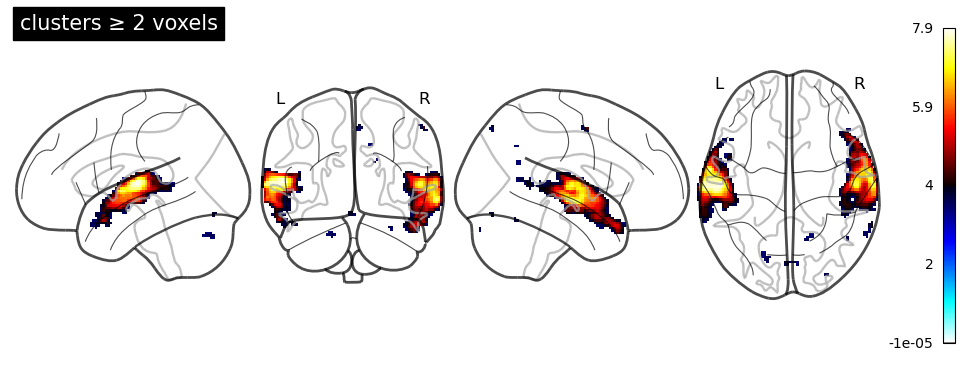

In [7]:
stat_img = image.load_img(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/social_over_physical_fdr05.png', dpi=300)  

plt.show()

display.close()

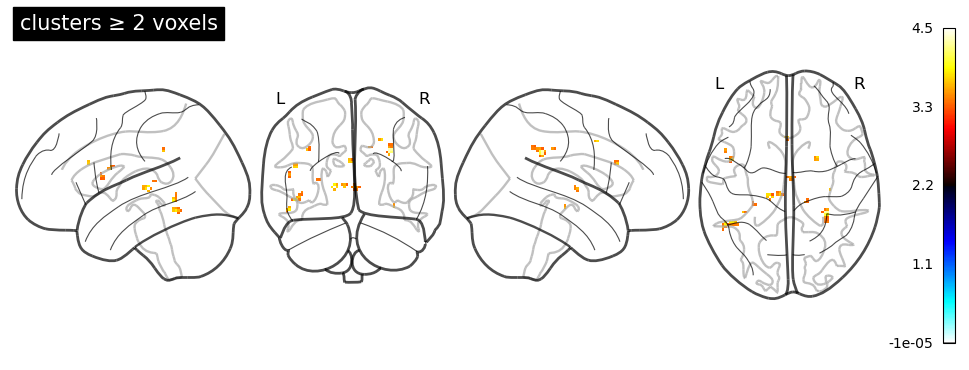

In [8]:
stat_img = image.load_img(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/physical_over_social_fdr05.png', dpi=300)  

plt.show()

display.close()

## split physical shapes data based on task order

In [6]:
TaskOrder = pd.read_csv(base_dir1+'NarrativesParticipants.csv')
TaskOrder = TaskOrder[['BIDS ID','Notes','Manipulation']]
TaskOrder = TaskOrder.dropna(how='all')
# remove duplicate rows, only 1 row per participant
TaskOrder = TaskOrder[TaskOrder['Manipulation'] == 'social']


In [7]:
TaskOrder

,BIDS ID,Notes,Manipulation
0,sub-049,"group2, social, movie, physical",social
2,sub-058,"group2, social, movie, physical",social
5,sub-095,"group1, movie, physical, social",social
6,sub-115,"group3, physical, social, movie",social
9,sub-127,"group1, movie, physical, social",social
11,sub-181,"group1, movie, social, physical",social
12,sub-186,"group2, social, movie, physical",social
14,sub-190,"group2, social, movie, physical",social
17,sub-191,"group1, movie, physical, social",social
19,sub-200,"group1, movie, social, physical",social


In [8]:
# Convert to string 
TaskOrder['BIDS ID'] = TaskOrder['BIDS ID'].astype(str).str.extract(r'(\d+)').astype(int)

group_df = TaskOrder[['BIDS ID', 'Notes']].copy()

# Extract group number
def extract_group(note):
    if pd.isna(note):
        return None
    if 'group1' in note:
        return 1
    elif 'group2' in note:
        return 2
    elif 'group3' in note:
        return 3
    else:
        return None

group_df['Group'] = group_df['Notes'].apply(extract_group)

# Drop Notes if you only want BIDS ID and Group
group_df = group_df[['BIDS ID', 'Group']]

# Sort by BIDS ID
group_df = group_df.sort_values(by='BIDS ID').reset_index(drop=True)



In [12]:
# Create a dataframe linking IDs and paths
df_files = pd.DataFrame({
    'BIDS ID': [int(re.search(r'/(\d+)_shapesphysical', f).group(1)) for f in files_physical],
    'path': files_physical
})

# Step 2: Merge with your group information
merged = df_files.merge(group_df, on='BIDS ID', how='inner')

# Step 3: Split based on group
files_physical_1 = merged.loc[merged['Group'] == 1, 'path'].tolist()
files_physical_2 = merged.loc[merged['Group'] == 2, 'path'].tolist()
files_physical_3 = merged.loc[merged['Group'] == 3, 'path'].tolist()


In [19]:
# Create a dataframe linking IDs and paths
df_files_social = pd.DataFrame({
    'BIDS ID': [int(re.search(r'/(\d+)_shapessocial', f).group(1)) for f in files_social],
    'path': files_social
})

# Step 2: Merge with your group information
merged_social = df_files_social.merge(group_df, on='BIDS ID', how='inner')

# Step 3: Split based on group
files_social_1 = merged_social.loc[merged['Group'] == 1, 'path'].tolist()
files_social_2 = merged_social.loc[merged['Group'] == 2, 'path'].tolist()
files_social_3 = merged_social.loc[merged['Group'] == 3, 'path'].tolist()


In [13]:
# group comparison# Create a dataframe describing each subject (row per file)
design_matrix = pd.DataFrame({
    'subject_label': merged['BIDS ID'],
    'group1': (merged['Group'] == 1).astype(int),
    'group2': (merged['Group'] == 2).astype(int),
    'group3': (merged['Group'] == 3).astype(int)
})

In [14]:
# Create a dataframe describing each subject (row per file)
design_matrix = pd.DataFrame({
    'subject_label': merged['BIDS ID'],
    'group1': (merged['Group'] == 1).astype(int),
    'group2': (merged['Group'] == 2).astype(int),
    'group3': (merged['Group'] == 3).astype(int)
})

In [16]:
second_level_input = merged['path'].tolist()

second_level_model = SecondLevelModel(
    mask_img=None,
)
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix
)

In [17]:

# === Define contrasts ===
contrasts = {
    'group1>group2': 'group1 - group2',
    'group2>group1': 'group2 - group1',
    'group1>group3': 'group1 - group3',
    'group3>group1': 'group3 - group1',
    'group2>group3': 'group2 - group3',
    'group3>group2': 'group3 - group2',
    '(group1+group2)>group3': 'group1 + group2 - 2*group3',
    'group3>(group1+group2)': '2*group3 - group1 - group2',
}

for name, formula in contrasts.items():
    print(f"\n🔹 Computing contrast: {name}")
    z_map = second_level_model.compute_contrast(
        formula,
        output_type='z_score'
    )
    
    # Save z-map
    zmap_path = os.path.join(
        str(output_dir),
        f"{name.replace('>', 'gt').replace('(', '').replace(')', '').replace('+', 'plus')}_zmap.nii.gz"
    )
    z_map.to_filename(zmap_path)


    # do correction

    thresholded_map, threshold = threshold_stats_img(
        stat_img=z_map,
        alpha=0.001,            # FDR level (start here)
        height_control='fpr',  # use 'bonferroni' for more conservative FWER control
        cluster_threshold=5,   # use >0 to filter small clusters
        two_sided=True        # or True if you want two-sided test
    )

    
    thresholded_map.to_filename(str(output_dir)+f"{name.replace('>', 'gt').replace('(', '').replace(')', '').replace('+', 'plus')}_zmap_fprCl5.nii.gz")
    
    print(threshold)
    
    create_output(str(output_dir)+f"{name.replace('>', 'gt').replace('(', '').replace(')', '').replace('+', 'plus')}_zmap_fprCl5.nii.gz",
                  cluster_extent=0,direction="pos",outdir=str(output_dir))
    




    
    # Save glass brain image
    fig_path = zmap_path.replace('.nii.gz', '_glassbrain.png')
    display = plotting.plot_glass_brain(
        thresholded_map,
        colorbar=True,
        title=name,
        display_mode='lyrz'
    )
    display.savefig(fig_path)
    display.close()



🔹 Computing contrast: group1>group2
3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)



🔹 Computing contrast: group2>group1
3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)



🔹 Computing contrast: group1>group3
3.2905267314918945


...

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)



🔹 Computing contrast: (group1+group2)>group3
3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)



🔹 Computing contrast: group3>(group1+group2)
3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


## run group 3 only (group with physical first)

/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_10387/2229931330.py:8: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


3.2905267314918945


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


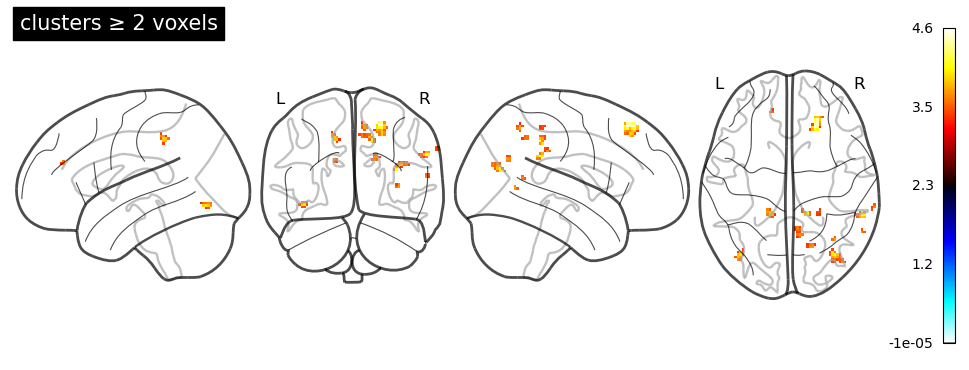

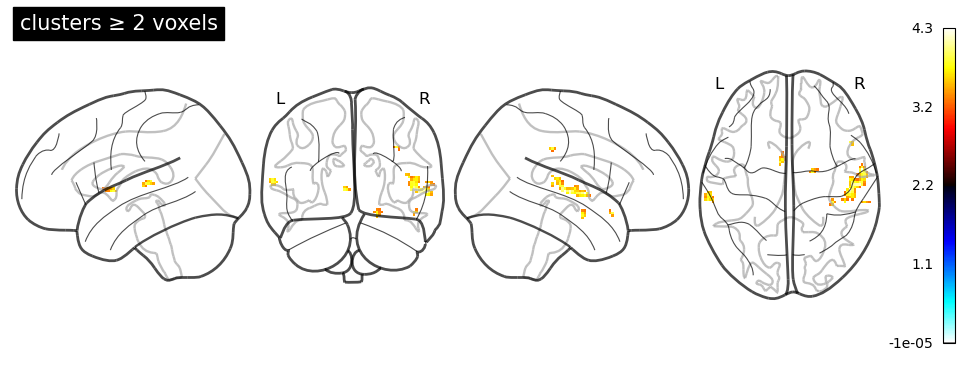

In [22]:



# 2. Convert PosixPaths → strings 
files_social_3 = [str(f) for f in files_social_3]
files_physical_3 = [str(f) for f in files_physical_3]

# 3. resample to same reference image
ref = files_social_3[0]
all_imgs = files_social_3 + files_physical_3
imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]

# Split back into conditions after resampling
n_subs = len(files_social_3)
imgs_social = imgs_resampled[:n_subs]
imgs_physical = imgs_resampled[n_subs:]

# 4. Compute within-subject difference maps (social - physical)
diff_imgs = [
    math_img("img1 - img2", img1=s, img2=p)
    for s, p in zip(imgs_social, imgs_physical)
]

# 5. design matrix
design_matrix = pd.DataFrame({'intercept': [1] * len(diff_imgs)})

# 6. Initialize and fit the second-level model
second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(diff_imgs, design_matrix=design_matrix)

# 7. Compute contrasts
# (a) Social > Physical
z_map_social_over_physical = second_level_model.compute_contrast(
    'intercept', output_type='z_score'
)
z_map_social_over_physical.to_filename(
    str(output_dir) + '/social_over_physical_zmap_group3.nii.gz'
)

# (b) Physical > Social
z_map_physical_over_social = second_level_model.compute_contrast(
    '-intercept', output_type='z_score'
)
z_map_physical_over_social.to_filename(
    str(output_dir) + '/physical_over_social_zmap_group3.nii.gz'
)




# do fpr correction, 5 voxels
thresholded_map, threshold_1 = threshold_stats_img(
    z_map_social_over_physical, alpha=0.001, height_control='fpr', cluster_threshold=5,
)
thresholded_map.to_filename(str(output_dir)+'/social_over_physical_group3_FPR5vox.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/social_over_physical_group3_FPR5vox.nii.gz',
              cluster_extent=5,direction="pos",outdir=str(output_dir))


# do fpr correction, 5 voxels
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_physical_over_social, alpha=0.001, height_control='fpr', cluster_threshold=5,
)
thresholded_map.to_filename(str(output_dir)+'/physical_over_social_group3_FPR5vox.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/physical_over_social_group3_FPR5vox.nii.gz',
              cluster_extent=5,direction="pos",outdir=str(output_dir))


stat_img = image.load_img(str(output_dir)+'/social_over_physical_group3_FPR5vox.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/social_over_physical_group3_FPR5vox.png', dpi=300)  

plt.show()

display.close()


stat_img = image.load_img(str(output_dir)+'/physical_over_social_group3_FPR5vox.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/physical_over_social_group3_FPR5vox.png', dpi=300)  

plt.show()

display.close()